# Practical Python Example 1

This is an example of using Python to automate a typical data analysis operations.

The source dataset is an Excel workbook containing [a fictitious dataset described here](https://zomalex.co.uk/datasets/montana_dataset.html).  This has a fact table, Store, and three related lookup tables: Countries, Products and Segments.

The Store table is in the 'Store Tab' worksheet.  
The Countries, Products and Segments tables are in the 'Lookups Tab' worksheet.

This Python script

* loads these Excel tables into pandas dataframes
* add some extra calculated columns to the Store dataframe
* merges the lookup tables into the Store table
* create a summary of the dataset
* plots this summary data as a bar chart
* exports the bar chart as a PNG file


In [1]:
import pandas as pd
import openpyxl

In [6]:
##data_xlsx_filepath = "./resources/montana-data-tables.xlsx"

data_xlsx_filepath ="/content/montana-data-tables.xlsx"

In [7]:
data_xlsx_filepath

'/content/montana-data-tables.xlsx'

Inspect the structure of the Excel workbook: sheets and tables

In [8]:
wb = openpyxl.load_workbook(filename=data_xlsx_filepath)
for sheet in wb.worksheets:
    print(f"Sheet: {sheet.title}")
    for table in sheet.tables:
        print(f"Table: {table} Range: {sheet.tables[table].ref}")


Sheet: Notes
Sheet: Store Tab
Table: Store Range: B3:M703
Sheet: Lookups Tab
Table: Segments Range: B5:D10
Table: Products Range: F5:H11
Table: Countries Range: J5:M10


The three Excel tables are on a worksheet named Lookups Tab.
We cannot load directly from an Excel table.  
Instead we retrieve the table name and range then use that information to import the data.

Create a function that returns the data in an Excel table as a dataframe.  We will use this for several tables.

In [10]:
def get_dataframe_from_table(wb, sheet_name, table_name):
    store_tab_sheet = wb[sheet_name]
    store_table = store_tab_sheet.tables[table_name]

    # Get the cell range for the table
    table_range = store_table.ref

    # Extract the cell values from the range
    data = store_tab_sheet[table_range] # This gives a tuple of tuples (rows of cells)
    # Convert to a list of lists (2D array) for easier DataFrame creation
    rows = [[cell.value for cell in row] for row in data]

    # Convert to DataFrame
    df = pd.DataFrame(rows[1:], columns=rows[0])
    return df


In [11]:
df_store = get_dataframe_from_table(wb, "Store Tab", "Store")
df_countries = get_dataframe_from_table(wb, "Lookups Tab", "Countries")
df_products = get_dataframe_from_table(wb, "Lookups Tab", "Products")
df_segments = get_dataframe_from_table(wb, "Lookups Tab", "Segments")

In [12]:
df_store

,TransactionId,OrderId,Segment,Country,Product,DiscountBand,Date,Quantity,UnitCost,SalePrice,COGS,Discount
0,T-90000,O-1219,Enterprise,Canada,Montana,None,2024-09-26,345.0,5,125,41400.0,0.00
1,T-90001,O-1358,Midmarket,Canada,Paseo,None,2023-08-27,549.0,10,15,5490.0,0.00
2,T-90002,O-1265,Small Business,Spain,Paseo,None,2023-05-16,788.0,10,300,197000.0,0.00
3,T-90003,O-1005,Government,Canada,Paseo,None,2023-08-02,1725.0,10,350,448500.0,0.00
4,T-90004,O-1174,Channel Partners,UK,Paseo,None,2024-06-29,912.0,10,12,2736.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
695,T-90695,O-1168,Small Business,France,Amarilla,High,2024-05-29,2475.0,260,300,618750.0,111375.00
696,T-90696,O-1145,Small Business,Spain,Amarilla,High,2023-05-18,546.0,260,300,136500.0,24570.00
697,T-90697,O-1235,Government,Spain,Montana,High,2023-02-09,1368.0,5,7,6840.0,1436.40
698,T-90698,O-1265,Government,Canada,Paseo,High,2024-05-21,723.0,10,7,3615.0,759.15


In [13]:
df_countries

,Country,Region,EU member,HQ
0,Canada,Americas,Not in EU,Toronto
1,France,Europe,In EU,Lyon
2,Spain,Europe,In EU,Lyon
3,UK,Europe,Not in EU,Frankfurt
4,Germany,Europe,In EU,Frankfurt


In [14]:
df_products

,Product,Brand,Tier
0,Montana,Rural,Gold
1,Paseo,Rural,Gold
2,Velo,Rural,Silver
3,VTT,Rural,Bronze
4,Carretera,Urban,Silver
5,Amarilla,Urban,Bronze


In [15]:
df_segments

,Segment,Sector,Channel
0,Enterprise,Big Companies,Direct
1,Midmarket,Small Companies,Indirect
2,Small Business,Small Companies,Indirect
3,Government,Public,Direct
4,Channel Partners,Big Companies,Indirect


Add three Calculated columns to the Store DataFrame.

* Gross Sales = SalePrice * Quantity
* Sales = Gross Sales - Discount
* Profit = Sales - COGS

In [16]:
##3 new fields added to df_store
df_store["Gross Sales"] = df_store["Quantity"] * df_store["SalePrice"]
df_store["Sales"] = df_store["Gross Sales"] - df_store["Discount"]
df_store["Profit"] = df_store["Sales"] - df_store["COGS"]

In [17]:
df_store

,TransactionId,OrderId,Segment,Country,Product,DiscountBand,Date,Quantity,UnitCost,SalePrice,COGS,Discount,Gross Sales,Sales,Profit
0,T-90000,O-1219,Enterprise,Canada,Montana,None,2024-09-26,345.0,5,125,41400.0,0.00,43125.0,43125.00,1725.00
1,T-90001,O-1358,Midmarket,Canada,Paseo,None,2023-08-27,549.0,10,15,5490.0,0.00,8235.0,8235.00,2745.00
2,T-90002,O-1265,Small Business,Spain,Paseo,None,2023-05-16,788.0,10,300,197000.0,0.00,236400.0,236400.00,39400.00
3,T-90003,O-1005,Government,Canada,Paseo,None,2023-08-02,1725.0,10,350,448500.0,0.00,603750.0,603750.00,155250.00
4,T-90004,O-1174,Channel Partners,UK,Paseo,None,2024-06-29,912.0,10,12,2736.0,0.00,10944.0,10944.00,8208.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,T-90695,O-1168,Small Business,France,Amarilla,High,2024-05-29,2475.0,260,300,618750.0,111375.00,742500.0,631125.00,12375.00
696,T-90696,O-1145,Small Business,Spain,Amarilla,High,2023-05-18,546.0,260,300,136500.0,24570.00,163800.0,139230.00,2730.00
697,T-90697,O-1235,Government,Spain,Montana,High,2023-02-09,1368.0,5,7,6840.0,1436.40,9576.0,8139.60,1299.60
698,T-90698,O-1265,Government,Canada,Paseo,High,2024-05-21,723.0,10,7,3615.0,759.15,5061.0,4301.85,686.85


Merge the three lookup tables into the Store table.

In [18]:
##like excel vlookup
## in sql like a join to dim table

df_store_merged = df_store.merge(df_countries, on='Country', how='left')
df_store_merged = df_store_merged.merge(df_products, on='Product', how='left')
df_store_merged = df_store_merged.merge(df_segments, on='Segment', how='left')
df_store_merged.columns

Index(['TransactionId', 'OrderId', 'Segment', 'Country', 'Product',
       'DiscountBand', 'Date', 'Quantity', 'UnitCost', 'SalePrice', 'COGS',
       'Discount', 'Gross Sales', 'Sales', 'Profit', 'Region', 'EU member',
       'HQ', 'Brand', 'Tier', 'Sector', 'Channel'],
      dtype='object')

In [19]:
##new columns added
df_store_merged

,TransactionId,OrderId,Segment,Country,Product,DiscountBand,Date,Quantity,UnitCost,SalePrice,...,Gross Sales,Sales,Profit,Region,EU member,HQ,Brand,Tier,Sector,Channel
0,T-90000,O-1219,Enterprise,Canada,Montana,None,2024-09-26,345.0,5,125,...,43125.0,43125.00,1725.00,Americas,Not in EU,Toronto,Rural,Gold,Big Companies,Direct
1,T-90001,O-1358,Midmarket,Canada,Paseo,None,2023-08-27,549.0,10,15,...,8235.0,8235.00,2745.00,Americas,Not in EU,Toronto,Rural,Gold,Small Companies,Indirect
2,T-90002,O-1265,Small Business,Spain,Paseo,None,2023-05-16,788.0,10,300,...,236400.0,236400.00,39400.00,Europe,In EU,Lyon,Rural,Gold,Small Companies,Indirect
3,T-90003,O-1005,Government,Canada,Paseo,None,2023-08-02,1725.0,10,350,...,603750.0,603750.00,155250.00,Americas,Not in EU,Toronto,Rural,Gold,Public,Direct
4,T-90004,O-1174,Channel Partners,UK,Paseo,None,2024-06-29,912.0,10,12,...,10944.0,10944.00,8208.00,Europe,Not in EU,Frankfurt,Rural,Gold,Big Companies,Indirect
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,T-90695,O-1168,Small Business,France,Amarilla,High,2024-05-29,2475.0,260,300,...,742500.0,631125.00,12375.00,Europe,In EU,Lyon,Urban,Bronze,Small Companies,Indirect
696,T-90696,O-1145,Small Business,Spain,Amarilla,High,2023-05-18,546.0,260,300,...,163800.0,139230.00,2730.00,Europe,In EU,Lyon,Urban,Bronze,Small Companies,Indirect
697,T-90697,O-1235,Government,Spain,Montana,High,2023-02-09,1368.0,5,7,...,9576.0,8139.60,1299.60,Europe,In EU,Lyon,Rural,Gold,Public,Direct
698,T-90698,O-1265,Government,Canada,Paseo,High,2024-05-21,723.0,10,7,...,5061.0,4301.85,686.85,Americas,Not in EU,Toronto,Rural,Gold,Public,Direct


In [20]:
##like pivot table sales by region and tier
df_sales_summary = df_store_merged.groupby(['Region', 'Tier'])['Sales'].sum().reset_index()
df_sales_summary

,Region,Tier,Sales
0,Americas,Bronze,8.624520e+06
1,Americas,Gold,1.033168e+07
2,Americas,Silver,5.939695e+06
3,Europe,Bronze,2.963452e+07
4,Europe,Gold,3.807027e+07
5,Europe,Silver,2.612567e+07


In [22]:
#df_sales_summary.to_csv("./outputs/sales-summary.csv", index=False)
df_sales_summary.to_csv("sales-summary.csv", index=False)

Create a chart from this Dataframe - a horizontal bar chart of Sales by Tier on the axis and Region on the legend.
Order the tiers as 'Gold', 'Silver', 'Bronze'


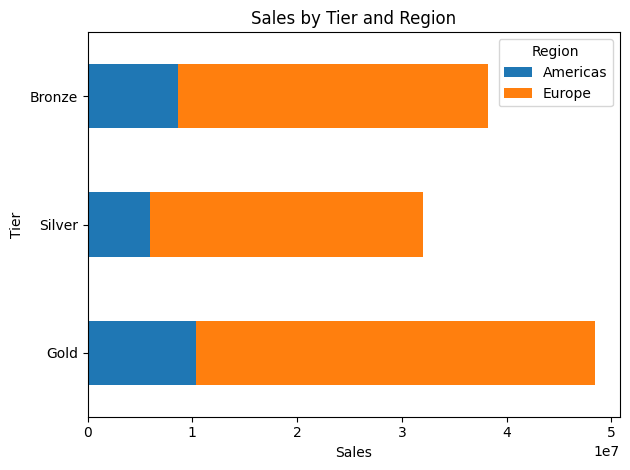

In [23]:
import matplotlib.pyplot as plt

df_pivot = df_sales_summary.pivot(index='Tier', columns='Region', values='Sales')

# Set the order for the index
tier_order = ['Gold', 'Silver', 'Bronze']
df_pivot.index = pd.CategoricalIndex(df_pivot.index, categories=tier_order, ordered=True)
df_pivot = df_pivot.sort_index()

df_pivot.plot(kind='barh', stacked=True)

plt.xlabel('Sales')
plt.title('Sales by Tier and Region')
plt.legend(title='Region')
plt.tight_layout()
plt.show()


Save the chart as an image file in the  outputs folder

In [24]:
fig, ax = plt.subplots()
df_pivot.plot(kind='barh', stacked=True, ax=ax)

ax.set_xlabel('Sales')
ax.set_title('Sales by Tier and Region')
ax.legend(title='Region')
plt.tight_layout()

plt.savefig('sales_by_tier_region.png')
##plt.savefig('./outputs/sales_by_tier_region.png')
plt.close(fig)